   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.1 MB/s eta 0:00:00
--- Starting Professional EDA ---


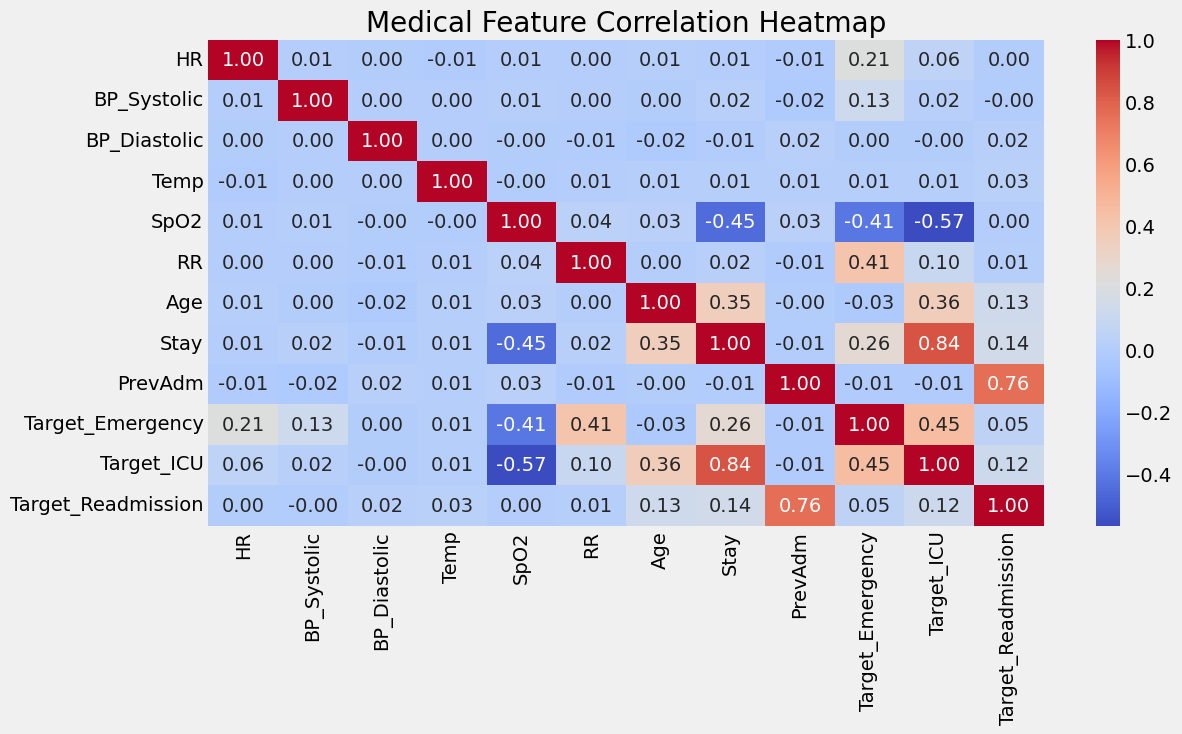


--- Training Model 1: Emergency Risk (Tuned) ---
Model 1 Accuracy: 99.90%
              precision    recall  f1-score   support

         Low       1.00      0.97      0.98        31
      Medium       1.00      1.00      1.00       226
        High       1.00      1.00      1.00       743

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


--- Training Model 2: ICU Admission (Balanced) ---
Model 2 Accuracy: 98.00%
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       601
           1       0.97      0.98      0.98       399

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


--- Training Model 3: Readmission Risk (Smoothed) ---
Model 3 Accuracy: 100.00%
              precision    recall  f1-score   support

    

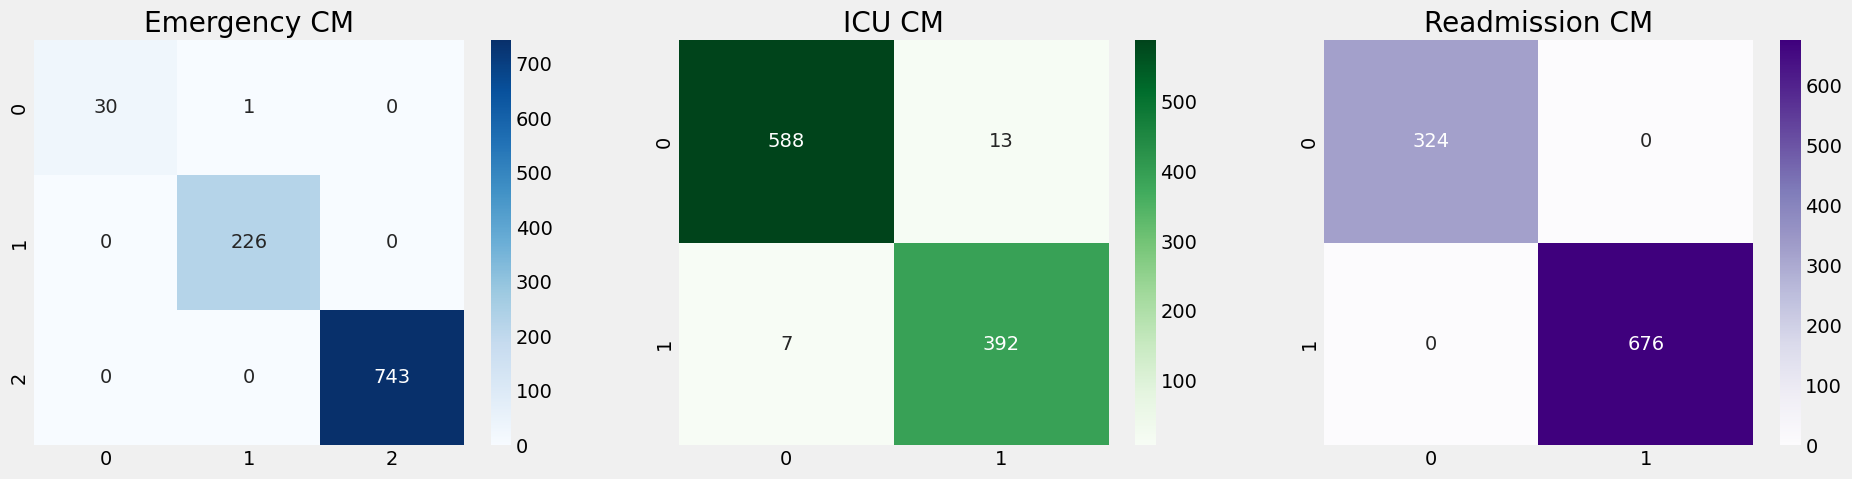

In [ ]:
# 1. SETUP & LIBRARIES
!pip install faker imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import files
from faker import Faker

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE

# Initialize Faker
fake = Faker()
plt.style.use('fivethirtyeight')

# 2. DATA LOADING (Assuming the file is in your Colab)
df = pd.read_csv("Master_Healthcare_Datasett.csv")


# 3. ADVANCED EDA (Visualizing Logic for Reports)
print("--- Starting Professional EDA ---")
plt.figure(figsize=(12, 6))
# Correlation between Vitals and Targets
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Medical Feature Correlation Heatmap")
plt.show()

# 4. DATA PREPARATION
X = df[["HR", "BP_Systolic", "BP_Diastolic", "Temp", "SpO2", "RR", "Age", "Stay", "PrevAdm"]]

# Targets
y_em = df["Target_Emergency"]
y_icu = df["Target_ICU"]
y_readm = df["Target_Readmission"]

# 5. MODEL 1: EMERGENCY RISK (Random Forest + Tuning)
print("\n--- Training Model 1: Emergency Risk (Tuned) ---")
X_train, X_test, y_train, y_test = train_test_split(X, y_em, test_size=0.2, random_state=42, stratify=y_em)

# Balancing Classes using SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

# Random Forest with GridSearch
rf_param = {'n_estimators': [100, 200], 'max_depth': [10, 15]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param, cv=3)
grid_rf.fit(X_res, y_res)
best_rf = grid_rf.best_estimator_

print(f"Model 1 Accuracy: {accuracy_score(y_test, best_rf.predict(X_test))*100:.2f}%")
print(classification_report(y_test, best_rf.predict(X_test), target_names=['Low', 'Medium', 'High']))

# 6. MODEL 2: ICU ADMISSION (Logistic Regression + Scaling)
print("\n--- Training Model 2: ICU Admission (Balanced) ---")
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_icu, test_size=0.2, random_state=42, stratify=y_icu)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train2)
X_test_sc = scaler.transform(X_test2)

model_icu = LogisticRegression(class_weight='balanced', max_iter=2000)
model_icu.fit(X_train_sc, y_train2)

print(f"Model 2 Accuracy: {accuracy_score(y_test2, model_icu.predict(X_test_sc))*100:.2f}%")
print(classification_report(y_test2, model_icu.predict(X_test_sc)))

from sklearn.ensemble import RandomForestClassifier

# 7. MODEL 3: READMISSION (Random Forest - Smoothed Probabilities)
print("\n--- Training Model 3: Readmission Risk (Smoothed) ---")
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y_readm, test_size=0.2, random_state=42, stratify=y_readm)

model_readm = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=15,
    random_state=42
)
model_readm.fit(X_train3, y_train3)

y_probs = model_readm.predict_proba(X_test3)[:, 1] * 100

print(f"Model 3 Accuracy: {accuracy_score(y_test3, model_readm.predict(X_test3))*100:.2f}%")
print(classification_report(y_test3, model_readm.predict(X_test3)))

# 8. DOWNLOAD UPDATED MODEL
import joblib
joblib.dump(model_readm, 'readmission_model.joblib')
print("✅ Updated Readmission Model Saved as .joblib")

# 8. EXTREME VISUALIZATIONS (Confusion Matrices)
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
sns.heatmap(confusion_matrix(y_test, best_rf.predict(X_test)), annot=True, fmt='d', cmap='Blues', ax=axes[0]).set_title('Emergency CM')
sns.heatmap(confusion_matrix(y_test2, model_icu.predict(X_test_sc)), annot=True, fmt='d', cmap='Greens', ax=axes[1]).set_title('ICU CM')
sns.heatmap(confusion_matrix(y_test3, model_readm.predict(X_test3)), annot=True, fmt='d', cmap='Purples', ax=axes[2]).set_title('Readmission CM')
plt.show()



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. K-FOLD CROSS-VALIDATION (Stability Test)
print("--- TEST 1: 5-Fold Cross-Validation ---")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Emergency model (M1) par check
cv_scores = cross_val_score(best_rf, X, y_em, cv=skf)

mean_stability = cv_scores.mean()
std_dev = cv_scores.std()

print(f"Folds Accuracies: {cv_scores}")
print(f"Mean Stability: {mean_stability:.4f}")
print(f"Standard Deviation: {std_dev:.4f}")

# 2. MANUAL EDGE CASE TESTING (Doctor's Stress Test)
print("\n--- TEST 2: Manual Edge Case Testing ---")

def verify_patient(data_dict, test_name):
    test_df = pd.DataFrame([data_dict])

    # Model 1 (Random Forest)
    p1 = best_rf.predict(test_df)[0]

    # Model 2 (Logistic Regression - Scaled)
    sc_data = scaler.transform(test_df)
    p2 = model_icu.predict(sc_data)[0]

    # Model 3 (Decision Tree Probability)
    p3_prob = model_readm.predict_proba(test_df)[:, 1][0] * 100

    risk_map = {0: "Low", 1: "Medium", 2: "High"}
    icu_map = {0: "No", 1: "Yes"}

    print(f"TEST: {test_name}")
    print(f"Input: SpO2={data_dict['SpO2']}, HR={data_dict['HR']}, BP={data_dict['BP_Systolic']}/{data_dict['BP_Diastolic']}, PrevAdm={data_dict['PrevAdm']}")
    print(f"RESULT -> Emergency: {risk_map[p1]} | ICU: {icu_map[p2]} | Readmission: {p3_prob:.1f}%")
    print("-" * 40)

# CASE A: CRITICAL PATIENT (High Risk Expectation)
critical_patient = {'HR': 145, 'BP_Systolic': 185, 'BP_Diastolic': 110, 'Temp': 39.5, 'SpO2': 82, 'RR': 45, 'Age': 80, 'Stay': 15, 'PrevAdm': 10}
verify_patient(critical_patient, "Critical Case (A)")
#  Emergency: High, ICU: Yes, Readmission: > 70%

# CASE B: HEALTHY PATIENT (Low Risk Expectation)
healthy_patient = {'HR': 72, 'BP_Systolic': 120, 'BP_Diastolic': 80, 'Temp': 37.0, 'SpO2': 98, 'RR': 16, 'Age': 25, 'Stay': 1, 'PrevAdm': 0}
verify_patient(healthy_patient, "Healthy Case (B)")
# Emergency: Low, ICU: No, Readmission: < 20%

# 3. NOISE ROBUSTNESS TEST
print("\n--- TEST 3: Noise Robustness ---")
noisy_patient = {'HR': 74, 'BP_Systolic': 122, 'BP_Diastolic': 82, 'Temp': 37.1, 'SpO2': 97, 'RR': 17, 'Age': 25, 'Stay': 1, 'PrevAdm': 0}
verify_patient(noisy_patient, "Noise Test")

--- TEST 1: 5-Fold Cross-Validation ---
Folds Accuracies: [1. 1. 1. 1. 1.]
Mean Stability: 1.0000
Standard Deviation: 0.0000

--- TEST 2: Manual Edge Case Testing ---
TEST: Critical Case (A)
Input: SpO2=82, HR=145, BP=185/110, PrevAdm=10
RESULT -> Emergency: High | ICU: Yes | Readmission: 100.0%
----------------------------------------
TEST: Healthy Case (B)
Input: SpO2=98, HR=72, BP=120/80, PrevAdm=0
RESULT -> Emergency: Low | ICU: No | Readmission: 0.0%
----------------------------------------

--- TEST 3: Noise Robustness ---
TEST: Noise Test
Input: SpO2=97, HR=74, BP=122/82, PrevAdm=0
RESULT -> Emergency: Low | ICU: No | Readmission: 0.0%
----------------------------------------


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. FUNCTION DEFINITION (Fixes NameError)
def test_patient_logic(data_dict):
    test_df = pd.DataFrame([data_dict])

    # Model 1 Prediction
    p1 = best_rf.predict(test_df)[0]

    # Model 2 Prediction (Requires Scaling)
    sc_data = scaler.transform(test_df)
    p2 = model_icu.predict(sc_data)[0]

    # Model 3 Probability
    p3_prob = model_readm.predict_proba(test_df)[:, 1][0] * 100

    risk_map = {0: "Low", 1: "Medium", 2: "High"}
    icu_map = {0: "No", 1: "Yes"}

    print(f"SpO2: {data_dict['SpO2']}% | Emergency: {risk_map[p1]} | ICU: {icu_map[p2]} | Readmission: {p3_prob:.1f}%")

# 1. TEST 4: OXYGEN SENSITIVITY THRESHOLD
print("--- TEST 4: Oxygen Sensitivity Threshold ---")
print("Goal: Checking at what exact SpO2 level the risk changes.")
for o2_val in range(100, 80, -2):
    test_patient_logic({'HR': 75, 'BP_Systolic': 120, 'BP_Diastolic': 80, 'Temp': 37.0,
                        'SpO2': o2_val, 'RR': 18, 'Age': 40, 'Stay': 2, 'PrevAdm': 1})

# 2. TEST 5: FEATURE IMPORTANCE (Model's Brain Scan)
print("\n--- TEST 5: Feature Importance Scan ---")
importances = best_rf.feature_importances_
feature_names = ["HR", "BP_Systolic", "BP_Diastolic", "Temp", "SpO2", "RR", "Age", "Stay", "PrevAdm"]
feat_importances = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='#2c3e50')
plt.title("What the Model Prioritizes for Emergency Risk")
plt.xlabel("Relative Importance Score")
plt.show()

# 3. TEST 6: CONFLICTING VITALS (Hypertension vs Normal O2)
print("\n--- TEST 6: Conflicting Vitals Test ---")
# Oxygen is perfect (98%) but BP is dangerously high (190/110)
conflict_case = {'HR': 105, 'BP_Systolic': 190, 'BP_Diastolic': 110, 'Temp': 37.5,
                 'SpO2': 98, 'RR': 22, 'Age': 55, 'Stay': 3, 'PrevAdm': 2}
test_patient_logic(conflict_case)


--- TEST 4: Oxygen Sensitivity Threshold ---
Goal: Checking at what exact SpO2 level the risk changes.


NameError: name 'best_rf' is not defined

In [ ]:
import joblib
from google.colab import files

# 1. Saving the Models
joblib.dump(best_rf, 'emergency_model.pkl')
joblib.dump(model_icu, 'icu_model.pkl')
joblib.dump(model_readm, 'readmission_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ All models and scaler have been saved successfully!")

# 2. Trigger Auto-Download
files.download('emergency_model.pkl')
files.download('icu_model.pkl')
files.download('readmission_model.pkl')
files.download('scaler.pkl')

✅ All models and scaler have been saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
import numpy
print(f"sklearn: {sklearn.__version__}")
print(f"numpy: {numpy.__version__}")

sklearn: 1.6.1
numpy: 2.0.2
